# Notebook 0: Theory and Applications. Approach to the problem

## 0.1) Theory behing the Mousetrap problem
The core idea is that there is a big box filled with mousetraps where two balls are balanced on it. A ball is thrown at random cuch that when it contacts the balls or mousetrap it makes the last clash down, making the other two rise up in the air and carry out a chain reaction.

### Applications of this chain reaction
This type of chain reaction can be used to model many different systems:
- Nuclear fission
- Epidemology (spread of diseases)
- Population dynamics
- Wildfire propagations (mousetraps are trees and ping-pong balls are burning ember)

### Different states possible if a discrete approach is taken
Taking a discrete approach to the problem, then the possible space is divided into cells of the same size and they can take up four distinct states. A cell can be inert, meaning it does not interact with the evolution of the system, it can be armed, meaning it will contribute to the evolution in the next timestep, it can be active, which is what happens to armed cells in the next timestep, and they can be dead, which is what happend to firing cells in the next timestep.

## 0.2) Approach to the problem
A simplified way of modelling this could be that we have an array that is divided into cells which are in state zero, but randomly one of them is flipped to one and there is a probability taht that one state will. ake nighboring cells also turn to one with a probabiulity that is inversely proportional to the distance to the distance to the one state. This is attempted with the following function:

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [3]:
import numpy as np

def simulate_MT_dynamics(rho, p0, kernel='exp', r0=3.0, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)      # 1 = armed trap present, 0 = empty
    state = np.where(grid == 1, 0, -1)                  # 0=armed, 1=fired, -1=no trap
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1 

    # This block defines a grid where -1 means it is permamently inert
    #, 0 means it is armed, 1 means it fired this generation and -2 means it
    # previously fired

    def p_of_d(d):
        if kernel == 'exp': # This is a type of evolution that evolves exponentially, symbolizing a characteristic exponential decay
            return p0 * np.exp(-d / r0)
        elif kernel == 'inv': # This describes a second type of evolution where there is a distinct distance cutoff
            return np.minimum(p0 / np.maximum(d, 1), 1.0) * (d <= r0)

    # This block taked a numpy array of distances and converts it into a 
    # triggering probability

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break #If there are no active firers, then the system will not change and the current timestep
            # will be outputted
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break # Same concept as before, if all the cells have shot out, then 
            # the system will remain constant and the current timestep will be outputted
        for fy, fx in fired:
            d = np.hypot(armed[:,0]-fy, armed[:,1]-fx) # distance from armed cell to taget cell
            hits = rng.random(len(d)) < p_of_d(d) # just a probability
            for (ay, ax) in armed[hits]:
                state[ay, ax] = 1
        state[state == 1] = np.where(rng.random(np.sum(state==1)) < 1, 2, 1)  # mark spent
        state[state == 2] = -2  # spent, distinct from empty
    return state # This is the code that takes care of the actual evolution of the system.
    # The output of the function is the state after the given number of timesteps

print(simulate_MT_dynamics(0.1, 0.1))

[[-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1  0 -1]
 [-1 -1 -1 ... -1 -1 -1]
 ...
 [-1 -1 -1 ...  0 -1 -1]
 [-1 -1  0 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1  0]]


It is convenient to store all the information of the evolution of a system inside a list of arrays so that we can then extract it in subsequent functions with varied uses: 

In [4]:
def history_MT_dynamics(rho, p0, kernel='exp', r0=3.0, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)      # 1 = armed trap present, 0 = empty
    state = np.where(grid == 1, 0, -1)                  # 0=armed, 1=fired, -1=no trap
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1 
    # This block defines a grid where -1 means it is permamently inert
    #, 0 means it is armed, 1 means it fired this generation and -2 means it
    # previously fired

    history = [state.copy()]  # record initial state as frame 0

    def p_of_d(d):
        if kernel == 'exp': # This is a type of evolution that evolves exponentially, symbolizinf a characteristic exponential decay
            return p0 * np.exp(-d / r0)
        elif kernel == 'inv': # This describes a second type of evolution where there is a distinct distance cutoff
            return np.minimum(p0 / np.maximum(d, 1), 1.0) * (d <= r0)
    # This block taked a numpy array of distances and converts it into a 
    # triggering probability

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break #If there are no active firers, then the system will not change and the current timestep
            # will be outputted
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break # Same concept as before, if all the cells have shot out, then 
            # the system will remain constant and the current timestep will be outputted
        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:,0]-fy, armed[:,1]-fx) # distance from armed cell to taget cell
            newly_hit |= rng.random(len(d)) < p_of_d(d) # just a probability
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        # spend only the cells that were already fired BEFORE this step
        # (not the ones freshly hit above — they get to fire next round)
        for fy, fx in fired:
            state[fy, fx] = -2

        history.append(state.copy())  # record this generation

    return history

In [5]:
hist = history_MT_dynamics(rho=0.4, p0=0.8, kernel='exp', r0=3.0, steps=300)

The following will be a function that extracts a timestep inside the evolution of a system and plots it on the grid, where white or blanck cells are inert, yellow are armed, red are firing and black means died out: 

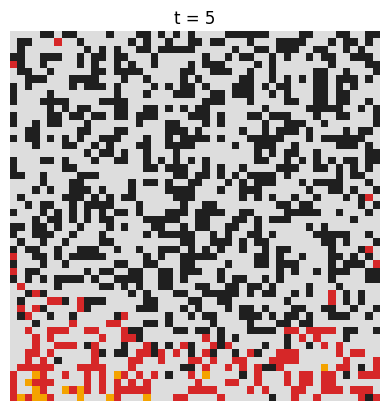

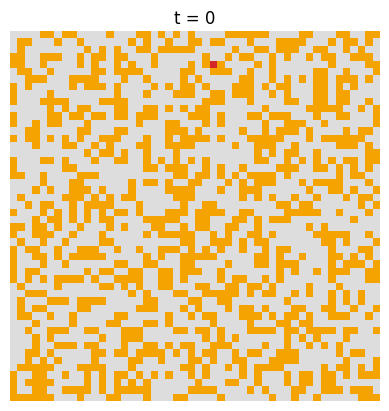

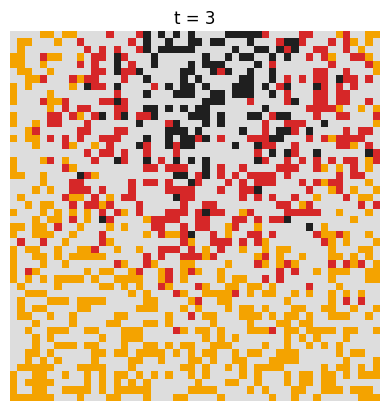

In [6]:
def show_timestep(history, t):
    """Display the grid state at timestep t from a history list."""
    if t < 0 or t >= len(history):
        raise ValueError(f"t={t} out of range; history has {len(history)} frames (0 to {len(history)-1})")

    state = history[t]

    # remap -1,0,1,-2 -> 0,1,2,3 for consistent coloring
    remap = {-1: 0, 0: 1, 1: 2, -2: 3}
    frame = np.vectorize(remap.get)(state)
    cmap = plt.matplotlib.colors.ListedColormap(
        ['#dddddd', '#f4a300', '#d62728', '#1f1f1f']  # inert, armed, firing, spent
    )

    fig, ax = plt.subplots()
    ax.imshow(frame, cmap=cmap, vmin=0, vmax=3)
    ax.set_title(f't = {t}')
    ax.axis('off')
    plt.show()

show_timestep(hist, 5)

show_timestep(hist, 0)

show_timestep(hist, 3)

Here, we animate the entire evolution:

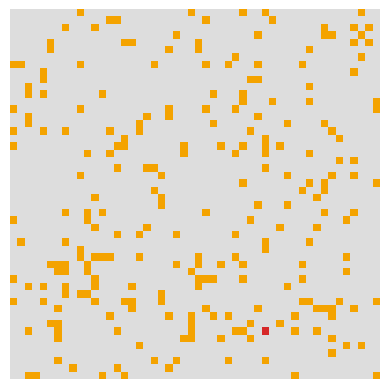

In [7]:
def animate_history(history, interval=150):
    remap = {-1: 0, 0: 1, 1: 2, -2: 3}
    cmap = plt.matplotlib.colors.ListedColormap(['#dddddd', '#f4a300', '#d62728', '#1f1f1f'])
    frames = [np.vectorize(remap.get)(f) for f in history]
    fig, ax = plt.subplots()
    im = ax.imshow(frames[0], cmap=cmap, vmin=0, vmax=3)
    ax.axis('off')
    def update(i):
        im.set_data(frames[i])
        ax.set_title(f't={i}')
        return [im]
    return FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=False)

hist = history_MT_dynamics(0.1, 0.1)
anim = animate_history(hist)
plt.show()

And finally, we plot the number of cells at each of the possible four states as a function of time:

Cascade ran for 7 frames


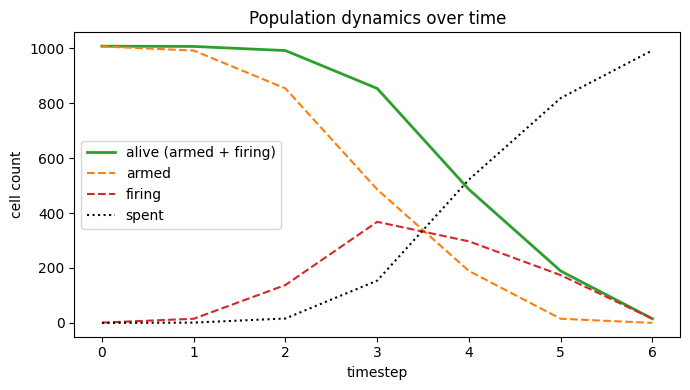

In [8]:
def plot_alive(history):
    """
    Plots counts of armed, firing, and spent cells at each timestep.
    'Alive' = armed (0) + firing (1); adjust as needed.
    """
    armed_counts  = [np.sum(s == 0)  for s in history]
    firing_counts = [np.sum(s == 1)  for s in history]
    spent_counts  = [np.sum(s == -2) for s in history]
    alive_counts  = [a + f for a, f in zip(armed_counts, firing_counts)]

    t = np.arange(len(history))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t, alive_counts, label='alive (armed + firing)', color='tab:green', lw=2)
    ax.plot(t, armed_counts, label='armed', color='tab:orange', ls='--')
    ax.plot(t, firing_counts, label='firing', color='tab:red', ls='--')
    ax.plot(t, spent_counts, label='spent', color='black', ls=':')
    ax.set_xlabel('timestep')
    ax.set_ylabel('cell count')
    ax.set_title('Population dynamics over time')
    ax.legend()
    plt.tight_layout()
    plt.show()

hist_dynamics = history_MT_dynamics(rho=0.4, p0=0.8, kernel='exp', r0=3.0, steps=300)
print(f"Cascade ran for {len(hist_dynamics)} frames")
plot_alive(hist_dynamics)

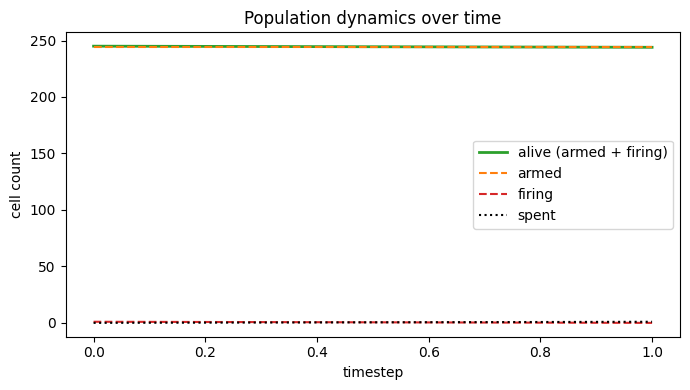

In [9]:
plot_alive(hist)

## 0.3) Modeling and short and long range interactions

Taking the mousetrap analogy, a nearby mousetrap can be activated by either the ball or the previously activated mousetrap, in our previous functions, we had only incorporated short range (mousetrap) interactions.

To incorporate long term interactions we have to identify another activation parameter with a probability of activation that increases as the distance increases until reaching a theoretical optimal point after which the probabiloty fo activation dies down exponentially.

We assume that the probabiloty increase and the increase in distance at short ranges is also exponential.

In this case, we will just have to take the original dynamics function and add this new term of activation:

In [10]:
import numpy as np

def p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall): # Long range kernel
    d = np.asarray(d, dtype=float)
    rising = d <= d_opt
    return np.where(
        rising,
        p0_ball * np.exp(-(d_opt - d) / r_rise),   # 0 -> p0_ball as d -> d_opt
        p0_ball * np.exp(-(d - d_opt) / r_fall)     # p0_ball -> 0 as d grows past d_opt
    )

def p_trap_of_d(d, p0_trap, r0_trap): # Short range kernel
    return p0_trap * np.exp(-d / r0_trap)

def _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall): # Calculates the probability associated
    # with both kernels
    p_trap = p_trap_of_d(d, p0_trap, r0_trap)
    p_ball = p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)
    return 1 - (1 - p_trap) * (1 - p_ball)


def simulate_MT_dynamics_v2(rho, p0_trap, r0_trap,
                             p0_ball, d_opt, r_rise, r_fall,
                             L=50, steps=200, rng=None): # This is the original dynamics function but the probability is now
    # the conjoined probability
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            p_total = _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall)
            newly_hit |= rng.random(len(d)) < p_total

        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2

    return state


def history_MT_dynamics_v2(rho, p0_trap, r0_trap,
                            p0_ball, d_opt, r_rise, r_fall,
                            L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    history = [state.copy()]

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            p_total = _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall)
            newly_hit |= rng.random(len(d)) < p_total

        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2

        history.append(state.copy())

    return history

Let's plot the evolution of the different states of the cells and the grid at the first 5 timesteps for an arbitrary system:

In [11]:
hist = history_MT_dynamics(rho=0.9, p0=0.8, kernel='exp', r0=3.0, steps=300)

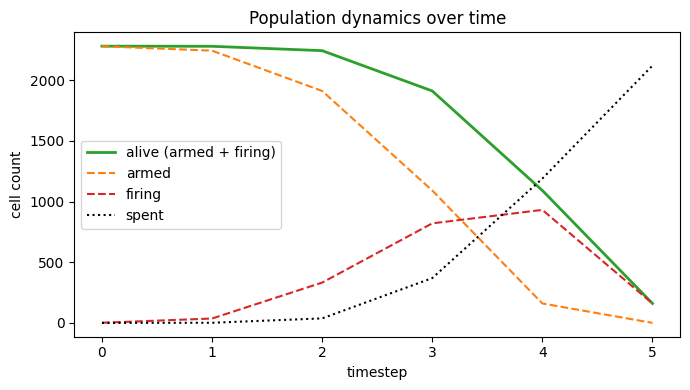

In [12]:
plot_alive(hist)

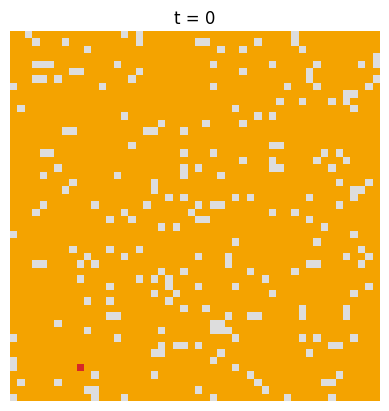

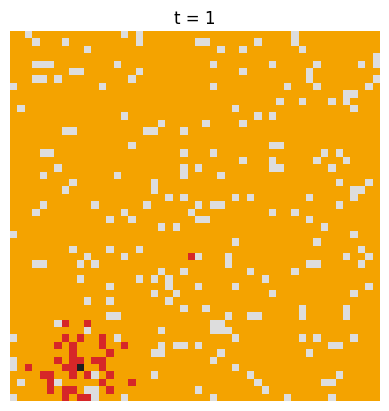

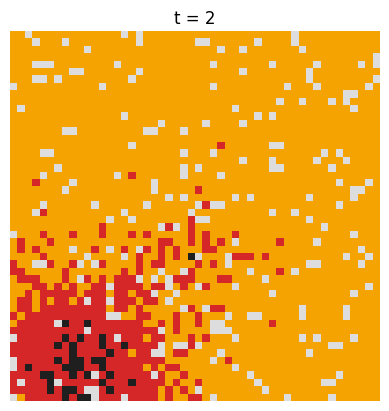

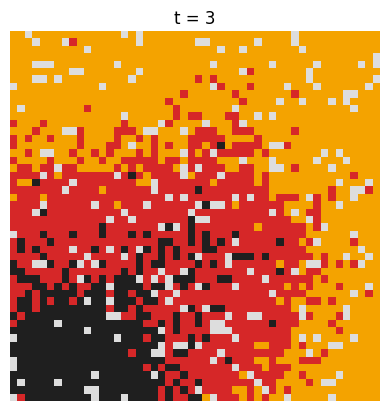

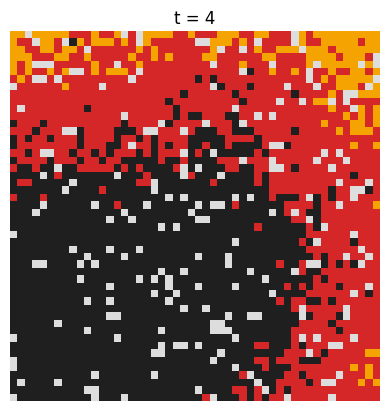

In [13]:
for i in range(5):
    show_timestep(hist, i)

## 0.4) Comparing short term, long term and conjoined interaction

### 0.4.1) Short term interaction

Here we'll define a function that only takes into account short term propagation, which is just the original dynamcis function:

In [14]:
def short_term_interaction(rho, p0, kernel='exp', r0=3.0, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)      # 1 = armed trap present, 0 = empty
    state = np.where(grid == 1, 0, -1)                  # 0=armed, 1=fired, -1=no trap
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1 

    # This block defines a grid where -1 means it is permamently inert
    #, 0 means it is armed, 1 means it fired this generation and -2 means it
    # previously fired

    def p_of_d(d):
        if kernel == 'exp': # This is a type of evolution that evolves exponentially, symbolizing a characteristic exponential decay
            return p0 * np.exp(-d / r0)
        elif kernel == 'inv': # This describes a second type of evolution where there is a distinct distance cutoff
            return np.minimum(p0 / np.maximum(d, 1), 1.0) * (d <= r0)

    # This block taked a numpy array of distances and converts it into a 
    # triggering probability

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break #If there are no active firers, then the system will not change and the current timestep
            # will be outputted
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break # Same concept as before, if all the cells have shot out, then 
            # the system will remain constant and the current timestep will be outputted
        for fy, fx in fired:
            d = np.hypot(armed[:,0]-fy, armed[:,1]-fx) # distance from armed cell to taget cell
            hits = rng.random(len(d)) < p_of_d(d) # just a probability
            for (ay, ax) in armed[hits]:
                state[ay, ax] = 1
        state[state == 1] = np.where(rng.random(np.sum(state==1)) < 1, 2, 1)  # mark spent
        state[state == 2] = -2  # spent, distinct from empty
    return state

### 0.4.2) Long term interaction

Here we define a dynamics function that only tjes into accout long term interaction, which is easy to do if we use the original probability functions, but this time the function takes the long-term probability instead of the conjoined probability as the true activation probability:

In [15]:
def long_term_interaction(rho, p0_ball, d_opt, r_rise, r_fall, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)     
    state = np.where(grid == 1, 0, -1)                  
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1


    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break 
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break  
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)  # distance from armed cell to target cell
            hits = rng.random(len(d)) < p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)  # long-term-only probability
            for (ay, ax) in armed[hits]:
                state[ay, ax] = 1
        state[state == 1] = np.where(rng.random(np.sum(state == 1)) < 1, 2, 1)  # mark spent
        state[state == 2] = -2  
    return state

### 0.4.3) Defining the system and performing the comparison

We define any arbitrary system through its conditions

In [16]:
system = history_MT_dynamics(rho=0.95, p0=0.85, kernel='exp', r0=3.5, steps=390)

## 0.5) Studying the behaviour of the density parameter
### 0.5.1) Plotting the percentage of cells deactivated vs the density as a function of time

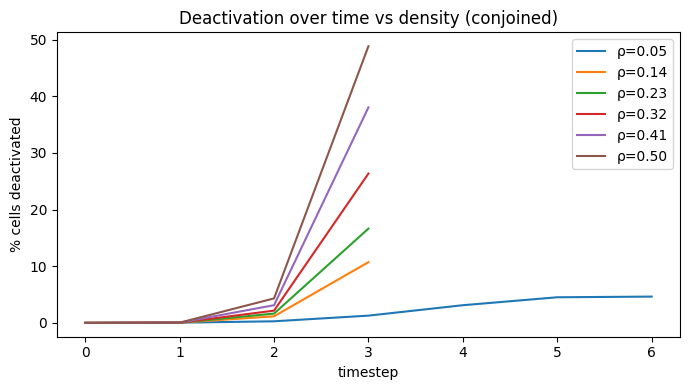

In [17]:
def plot_deactivated_vs_density_time(rho_values, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall,
                                      L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    fig, ax = plt.subplots(figsize=(7, 4))

    for rho in rho_values:
        hist = history_MT_dynamics_v2(rho, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall,
                                       L=L, steps=steps, rng=rng)
        pct_deactivated = [100 * np.sum(s == -2) / (L * L) for s in hist]
        ax.plot(pct_deactivated, label=f'ρ={rho:.2f}')

    ax.set_xlabel('timestep')
    ax.set_ylabel('% cells deactivated')
    ax.set_title('Deactivation over time vs density (conjoined)')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_deactivated_vs_density_time(np.linspace(0.05, 0.5, 6), 0.8, 3, 0.3, 10, 3, 5,
                                      L=50, steps=200, rng=None)

### 0.5.2) Plotting the percentage of cells deactivated vs the density as a function of time for all possible probability settings

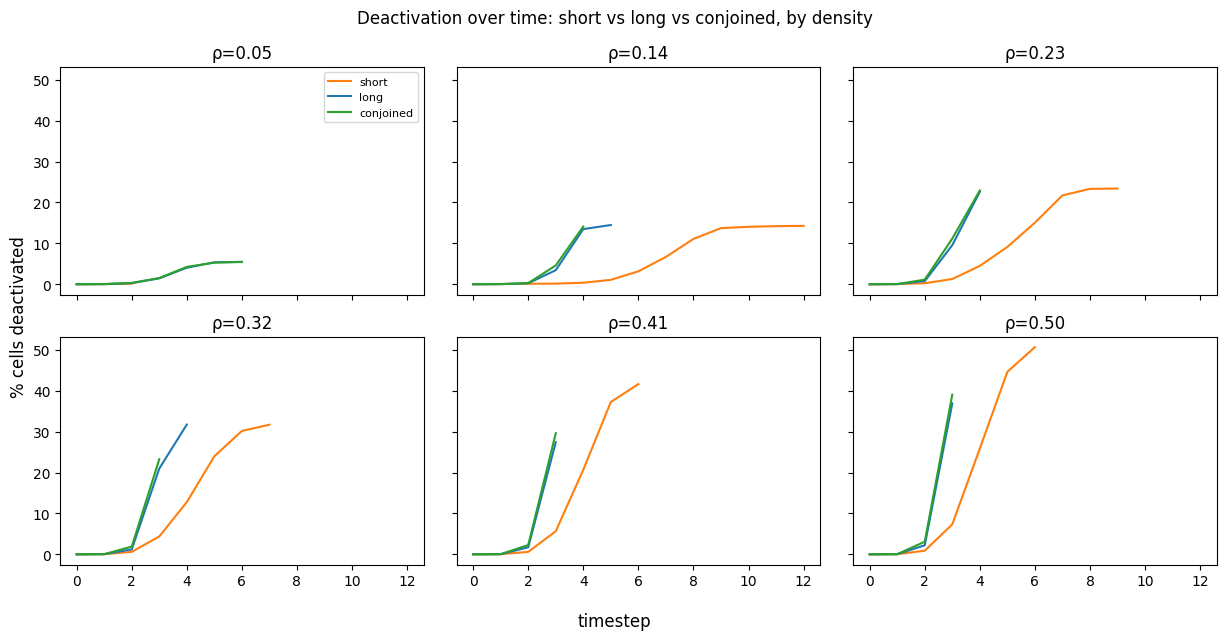

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall):
    d = np.asarray(d, dtype=float)
    rising = d <= d_opt
    return np.where(
        rising,
        p0_ball * np.exp(-(d_opt - d) / r_rise),
        p0_ball * np.exp(-(d - d_opt) / r_fall)
    )

def p_trap_of_d(d, p0_trap, r0_trap):
    return p0_trap * np.exp(-d / r0_trap)

def _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall):
    p_trap = p_trap_of_d(d, p0_trap, r0_trap)
    p_ball = p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)
    return 1 - (1 - p_trap) * (1 - p_ball)

def _init_grid(rho, L, rng): # Builds the starting state for one simulation run
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1
    return state

def history_short(rho, p0_trap, r0_trap, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    state = _init_grid(rho, L, rng)
    history = [state.copy()]
    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0: break
        armed = np.argwhere(state == 0)
        if len(armed) == 0: break
        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit |= rng.random(len(d)) < p_trap_of_d(d, p0_trap, r0_trap)
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2
        history.append(state.copy())
    return history

def history_long(rho, p0_ball, d_opt, r_rise, r_fall, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    state = _init_grid(rho, L, rng)
    history = [state.copy()]
    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0: break
        armed = np.argwhere(state == 0)
        if len(armed) == 0: break
        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit |= rng.random(len(d)) < p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2
        history.append(state.copy())
    return history

def history_conjoined(rho, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    state = _init_grid(rho, L, rng)
    history = [state.copy()]
    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0: break
        armed = np.argwhere(state == 0)
        if len(armed) == 0: break
        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            p_total = _combined_p_of_d(d, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall)
            newly_hit |= rng.random(len(d)) < p_total
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2
        history.append(state.copy())
    return history

def pct_deactivated(history, L):
    return [100 * np.sum(s == -2) / (L * L) for s in history] # To obtain teh y-axis values for the plot

def plot_all_settings_vs_density_time(rho_values, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall,
                                       L=50, steps=200, seed=0):
    n = len(rho_values)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for i, rho in enumerate(rho_values):
        ax = axes[i]
        rng_s = np.random.default_rng(seed)
        rng_l = np.random.default_rng(seed)
        rng_c = np.random.default_rng(seed)

        h_short = history_short(rho, p0_trap, r0_trap, L=L, steps=steps, rng=rng_s)
        h_long  = history_long(rho, p0_ball, d_opt, r_rise, r_fall, L=L, steps=steps, rng=rng_l)
        h_conj  = history_conjoined(rho, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall,
                                     L=L, steps=steps, rng=rng_c)

        ax.plot(pct_deactivated(h_short, L), label='short', color='tab:orange')
        ax.plot(pct_deactivated(h_long, L),  label='long',  color='tab:blue')
        ax.plot(pct_deactivated(h_conj, L),  label='conjoined', color='tab:green')
        ax.set_title(f'ρ={rho:.2f}')

    for ax in axes[n:]:
        ax.axis('off')

    axes[0].legend(fontsize=8)
    fig.supxlabel('timestep')
    fig.supylabel('% cells deactivated')
    fig.suptitle('Deactivation over time: short vs long vs conjoined, by density')
    plt.tight_layout()
    plt.show()

rho_values = np.linspace(0.05, 0.5, 6)
p0_trap, r0_trap = 0.8, 3.0
p0_ball, d_opt, r_rise, r_fall = 0.3, 10.0, 3.0, 5.0
L, steps = 50, 200

plot_all_settings_vs_density_time(rho_values, p0_trap, r0_trap, p0_ball, d_opt, r_rise, r_fall,
                                   L=L, steps=steps, seed=0)

## 0.6 Playing around with the density

### 0.6.1) Different initial conditions and changing the density
Here the dynamics and history function are redefined such that there is an input that determined the probability of a cell being turned into an initial condition:

In [19]:
def _init_grid_random(rho, p_active, L, rng):
    grid = (rng.random((L, L)) < rho).astype(int)          # 1 = trap present
    state = np.where(grid == 1, 0, -1)                      # 0=armed, -1=no trap
    trap_mask = grid == 1
    active_mask = trap_mask & (rng.random((L, L)) < p_active)  # each trap independently active w.p. p_active
    state[active_mask] = 1
    return state


def simulate_dynamics(rho, p_active, p_of_d_func, L=50, steps=200, rng=None):
    def _init_grid_random(rho, p_active, L, rng):
        grid = (rng.random((L, L)) < rho).astype(int)          # 1 = trap present
        state = np.where(grid == 1, 0, -1)                      # 0=armed, -1=no trap
        trap_mask = grid == 1
        active_mask = trap_mask & (rng.random((L, L)) < p_active)  # each trap independently active w.p. p_active
        state[active_mask] = 1
        return state
    
    rng = rng or np.random.default_rng()
    state = _init_grid_random(rho, p_active, L, rng)

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit |= rng.random(len(d)) < p_of_d_func(d)
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2

    return state


def history_dynamics(rho, p_active, p_of_d_func, L=50, steps=200, rng=None):
    def _init_grid_random(rho, p_active, L, rng):
        grid = (rng.random((L, L)) < rho).astype(int)          # 1 = trap present
        state = np.where(grid == 1, 0, -1)                      # 0=armed, -1=no trap
        trap_mask = grid == 1
        active_mask = trap_mask & (rng.random((L, L)) < p_active)  # each trap independently active w.p. p_active
        state[active_mask] = 1
        return state
    rng = rng or np.random.default_rng()
    state = _init_grid_random(rho, p_active, L, rng)
    history = [state.copy()]

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit |= rng.random(len(d)) < p_of_d_func(d)
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2

        history.append(state.copy())

    return history

## 0.7) Polishing up the code
### 0.7.1) Redefining the short term interaction such that it only interacts with neighboring cells
If the short term interaction is modified such that it only affects neighboring cells, then the dynamics will resemble processes like nuclear fission or wildfire propagation in a much better way. 

In this case two different neighborhoods can be defined, Moore or von Neumann. A Moore neighbihood means that all eight neighboring cells can be affected, whilst in a von Neumann neighborhood only the four orthogonal cells count.

In [20]:
import numpy as np

def p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall):  # Long range kernel (from your notebook)
    d = np.asarray(d, dtype=float)
    rising = d <= d_opt
    return np.where(
        rising,
        p0_ball * np.exp(-(d_opt - d) / r_rise),   # 0 -> p0_ball as d -> d_opt
        p0_ball * np.exp(-(d - d_opt) / r_fall)    # p0_ball -> 0 as d grows past d_opt
    )


def short_and_long_term_interaction_neighbors(rho, p, p0_ball, d_opt, r_rise, r_fall,
                                               L=50, steps=200, neighborhood='moore', rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    if neighborhood == 'moore':
        offsets = [(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1) if not (dy == 0 and dx == 0)]
    elif neighborhood == 'von_neumann':
        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        raise ValueError("neighborhood must be 'moore' or 'von_neumann'")

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit_long = np.zeros(len(armed), dtype=bool)   # indexed against `armed`
        newly_hit_short = set()                              # explicit (y, x) coords

        for fy, fx in fired:
            # --- long-range: any armed cell, probability from the distance kernel ---
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit_long |= rng.random(len(d)) < p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)

            # --- short-range: only immediate neighbors, flat input probability p ---
            for dy, dx in offsets:
                ny, nx = fy + dy, fx + dx
                if 0 <= ny < L and 0 <= nx < L and state[ny, nx] == 0:
                    if rng.random() < p:
                        newly_hit_short.add((ny, nx))

        for (ay, ax) in armed[newly_hit_long]:
            state[ay, ax] = 1
        for (ny, nx) in newly_hit_short:
            state[ny, nx] = 1

        for fy, fx in fired:
            state[fy, fx] = -2

    return state


def history_short_and_long_term_interaction_neighbors(rho, p, p0_ball, d_opt, r_rise, r_fall,
                                                        L=50, steps=200, neighborhood='moore', rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    history = [state.copy()]

    if neighborhood == 'moore':
        offsets = [(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1) if not (dy == 0 and dx == 0)]
    elif neighborhood == 'von_neumann':
        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        raise ValueError("neighborhood must be 'moore' or 'von_neumann'")

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        armed = np.argwhere(state == 0)
        if len(armed) == 0:
            break

        newly_hit_long = np.zeros(len(armed), dtype=bool)
        newly_hit_short = set()

        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit_long |= rng.random(len(d)) < p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)

            for dy, dx in offsets:
                ny, nx = fy + dy, fx + dx
                if 0 <= ny < L and 0 <= nx < L and state[ny, nx] == 0:
                    if rng.random() < p:
                        newly_hit_short.add((ny, nx))

        for (ay, ax) in armed[newly_hit_long]:
            state[ay, ax] = 1
        for (ny, nx) in newly_hit_short:
            state[ny, nx] = 1

        for fy, fx in fired:
            state[fy, fx] = -2   # spend only cells that fired BEFORE this step

        history.append(state.copy())

    return history

### 0.7.2) Modifying the decay plots
In order to study the decay of the system at different settings, it would be useful to see how each function ends up flattening out. For this, we redefine the dynamics function such that it doesn't stop computing the next timesteps once all cells are inert or decayed (which was put in with an if else statetement):

In [21]:
def short_term_interaction_neighbors(rho, p, L=50, steps=200, neighborhood='moore', rng=None):

    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)     
    state = np.where(grid == 1, 0, -1)                 
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1                     

    if neighborhood == 'moore':
        offsets = [(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1) if not (dy == 0 and dx == 0)]
    elif neighborhood == 'von_neumann':
        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        raise ValueError("neighborhood must be 'moore' or 'von_neumann'")

    for t in range(steps):                           
        fired = np.argwhere(state == 1)

        newly_hit = set()
        for fy, fx in fired:
            for dy, dx in offsets:                   
                ny, nx = fy + dy, fx + dx
                if 0 <= ny < L and 0 <= nx < L and state[ny, nx] == 0:
                    if rng.random() < p:              
                        newly_hit.add((ny, nx))

        for ny, nx in newly_hit:
            state[ny, nx] = 1                          
        for fy, fx in fired:
            state[fy, fx] = -2                        

    return state


def history_short_term_interaction_neighbors(rho, p, L=50, steps=200, neighborhood='moore', rng=None):

    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)     
    state = np.where(grid == 1, 0, -1)               
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    history = [state.copy()]                            

    if neighborhood == 'moore':
        offsets = [(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1) if not (dy == 0 and dx == 0)]
    elif neighborhood == 'von_neumann':
        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        raise ValueError("neighborhood must be 'moore' or 'von_neumann'")

    for t in range(steps):                            
        fired = np.argwhere(state == 1)

        newly_hit = set()
        for fy, fx in fired:
            for dy, dx in offsets:
                ny, nx = fy + dy, fx + dx
                if 0 <= ny < L and 0 <= nx < L and state[ny, nx] == 0:
                    if rng.random() < p:
                        newly_hit.add((ny, nx))

        for ny, nx in newly_hit:
            state[ny, nx] = 1
        for fy, fx in fired:
            state[fy, fx] = -2                          

        history.append(state.copy())                   

    return history

Now we remodify the previous code so that it now works with the previous, modified functions:

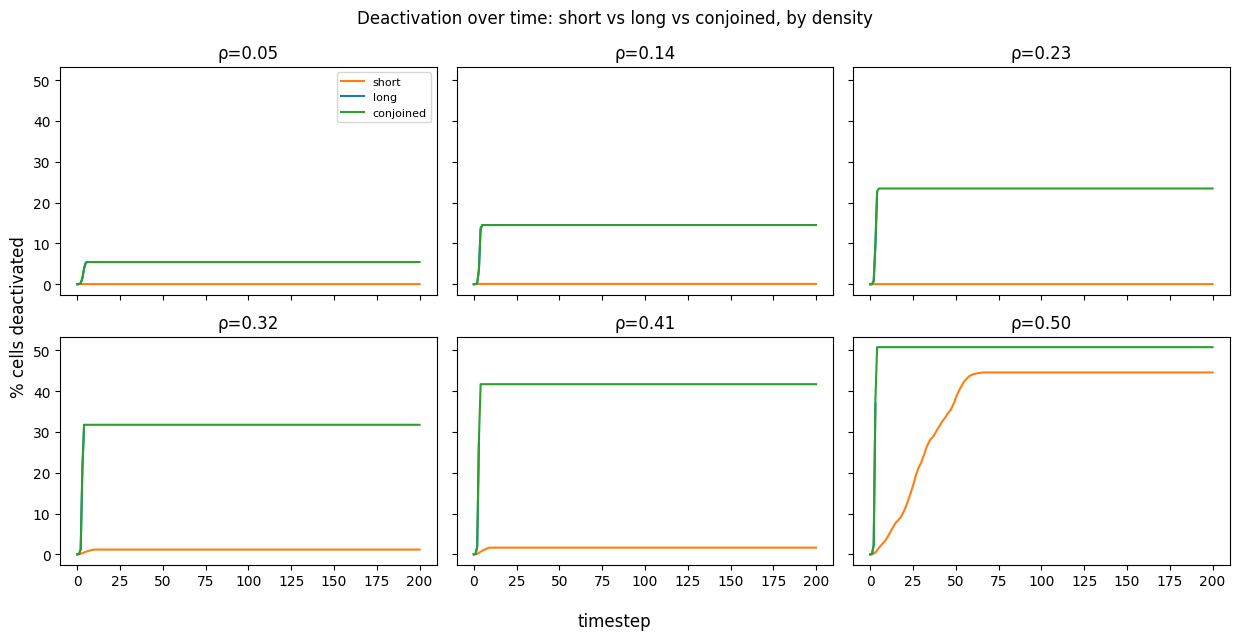

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall):
    d = np.asarray(d, dtype=float)
    rising = d <= d_opt
    return np.where(
        rising,
        p0_ball * np.exp(-(d_opt - d) / r_rise),
        p0_ball * np.exp(-(d - d_opt) / r_fall)
    )

def _init_grid(rho, L, rng):  # Builds the starting state for one simulation run
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1
    return state

def _neighbor_offsets(neighborhood):
    if neighborhood == 'moore':
        return [(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1) if not (dy == 0 and dx == 0)]
    elif neighborhood == 'von_neumann':
        return [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        raise ValueError("neighborhood must be 'moore' or 'von_neumann'")

def history_short(rho, p, L=50, steps=200, neighborhood='moore', rng=None):

    rng = rng or np.random.default_rng()
    state = _init_grid(rho, L, rng)
    history = [state.copy()]
    offsets = _neighbor_offsets(neighborhood)

    for t in range(steps):
        fired = np.argwhere(state == 1)
        newly_hit = set()
        for fy, fx in fired:
            for dy, dx in offsets:
                ny, nx = fy + dy, fx + dx
                if 0 <= ny < L and 0 <= nx < L and state[ny, nx] == 0:
                    if rng.random() < p:
                        newly_hit.add((ny, nx))
        for ny, nx in newly_hit:
            state[ny, nx] = 1
        for fy, fx in fired:
            state[fy, fx] = -2
        history.append(state.copy())
    return history

def history_long(rho, p0_ball, d_opt, r_rise, r_fall, L=50, steps=200, rng=None):
   
    rng = rng or np.random.default_rng()
    state = _init_grid(rho, L, rng)
    history = [state.copy()]
    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0: break
        armed = np.argwhere(state == 0)
        if len(armed) == 0: break
        newly_hit = np.zeros(len(armed), dtype=bool)
        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit |= rng.random(len(d)) < p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)
        for (ay, ax) in armed[newly_hit]:
            state[ay, ax] = 1
        for fy, fx in fired:
            state[fy, fx] = -2
        history.append(state.copy())
    return history

def history_conjoined(rho, p, p0_ball, d_opt, r_rise, r_fall, L=50, steps=200, neighborhood='moore', rng=None):

    rng = rng or np.random.default_rng()
    state = _init_grid(rho, L, rng)
    history = [state.copy()]
    offsets = _neighbor_offsets(neighborhood)

    for t in range(steps):
        fired = np.argwhere(state == 1)
        armed = np.argwhere(state == 0)

        newly_hit_long = np.zeros(len(armed), dtype=bool)
        newly_hit_short = set()

        for fy, fx in fired:
            d = np.hypot(armed[:, 0] - fy, armed[:, 1] - fx)
            newly_hit_long |= rng.random(len(d)) < p_ball_of_d(d, p0_ball, d_opt, r_rise, r_fall)

            for dy, dx in offsets:
                ny, nx = fy + dy, fx + dx
                if 0 <= ny < L and 0 <= nx < L and state[ny, nx] == 0:
                    if rng.random() < p:
                        newly_hit_short.add((ny, nx))

        for (ay, ax) in armed[newly_hit_long]:
            state[ay, ax] = 1
        for (ny, nx) in newly_hit_short:
            state[ny, nx] = 1
        for fy, fx in fired:
            state[fy, fx] = -2

        history.append(state.copy())
    return history

def pct_deactivated(history, L):
    return [100 * np.sum(s == -2) / (L * L) for s in history]  # To obtain the y-axis values for the plot

def plot_all_settings_vs_density_time(rho_values, p, p0_ball, d_opt, r_rise, r_fall,
                                       L=50, steps=200, neighborhood='moore', seed=0):
    n = len(rho_values)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for i, rho in enumerate(rho_values):
        ax = axes[i]
        rng_s = np.random.default_rng(seed)
        rng_l = np.random.default_rng(seed)
        rng_c = np.random.default_rng(seed)

        h_short = history_short(rho, p, L=L, steps=steps, neighborhood=neighborhood, rng=rng_s)
        h_long  = history_long(rho, p0_ball, d_opt, r_rise, r_fall, L=L, steps=steps, rng=rng_l)
        h_conj  = history_conjoined(rho, p, p0_ball, d_opt, r_rise, r_fall,
                                     L=L, steps=steps, neighborhood=neighborhood, rng=rng_c)

        ax.plot(pct_deactivated(h_short, L), label='short', color='tab:orange')
        ax.plot(pct_deactivated(h_long, L),  label='long',  color='tab:blue')
        ax.plot(pct_deactivated(h_conj, L),  label='conjoined', color='tab:green')
        ax.set_title(f'ρ={rho:.2f}')

    for ax in axes[n:]:
        ax.axis('off')

    axes[0].legend(fontsize=8)
    fig.supxlabel('timestep')
    fig.supylabel('% cells deactivated')
    fig.suptitle('Deactivation over time: short vs long vs conjoined, by density')
    plt.tight_layout()
    plt.show()

rho_values = np.linspace(0.05, 0.5, 6)
p = 0.8                                      # short-range neighbor activation probability (replaces p0_trap/r0_trap)
p0_ball, d_opt, r_rise, r_fall = 0.3, 10.0, 3.0, 5.0
L, steps = 50, 200

plot_all_settings_vs_density_time(rho_values, p, p0_ball, d_opt, r_rise, r_fall,
                                   L=L, steps=steps, neighborhood='moore', seed=0)

## 0.7.3) Finalizing the decay plots, making it cap out at 100%
As can be seen in the plot above, the plots plateau at percentages below 100%, for aesthetical reasons, we will redefine what the plots mean so that the plateau reaches 100%.

In order to do so, the percentage instead of only including deactivated cells, it will also include inert ones.

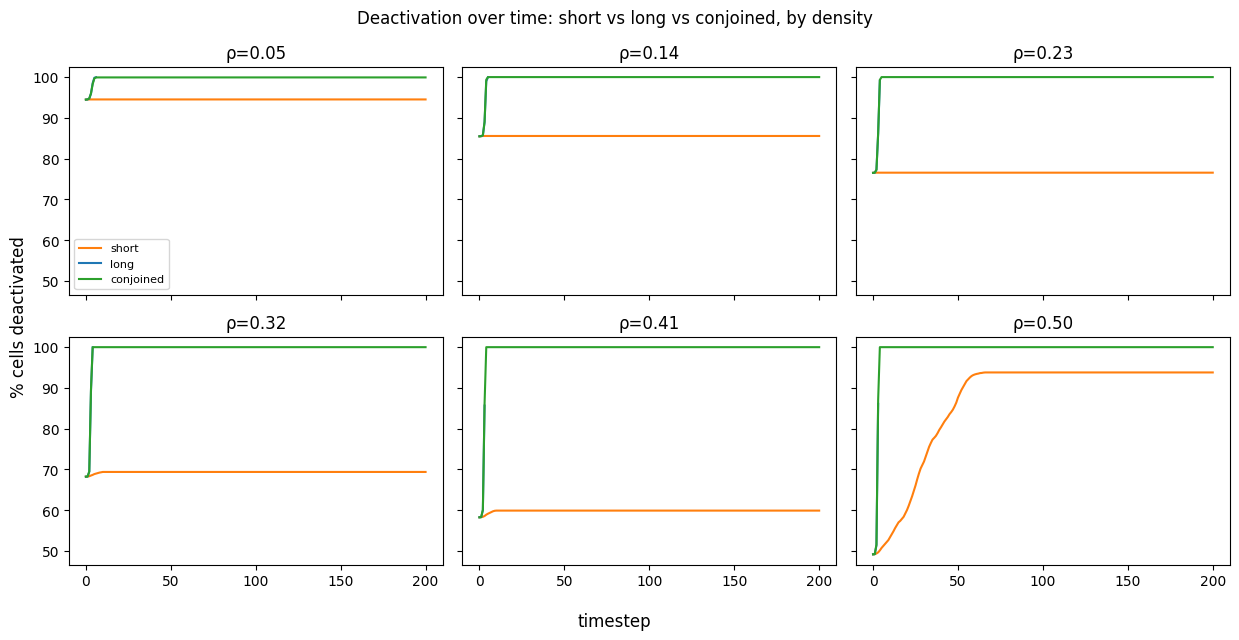

In [23]:
def pct_deactivated(history, L):
    return [100 * (np.sum(s == -2) + np.sum(s == -1)) / (L * L) for s in history]

plot_all_settings_vs_density_time(rho_values, p, p0_ball, d_opt, r_rise, r_fall,
                                   L=L, steps=steps, neighborhood='moore', seed=0)

calculate percentage without looking at ienr cells (empty space) such that it starts at 0% and ends at 100%

## 0.8) Redefining how long-range propagation works
Short-term progagation has already been correctly defined, such that there is a chance that a maximum of one neigboring cell is activated, with several neighbor configurations.

For the new long-range configuration, instead of each inidividual cell having an associated indeopendent probbaility of being activated, such that in theory every cell could be activated by an active cell form the previous timestep, we'll define the activation such that at maximum only one cell can be activated.

The algorithm of activation will work following these steps:
- We have a probability density function such that an arbitrary natural number is chosen.
- The code finds the cells that are that number of cells away from the active cell.
- The code randomly chooses only one of those cells.
- The code then, via an associated probability, activates or not that cell.
- This same process is repeated for all active cells within that same timestep.

Knowing this, we can start defining the code in order to finally obtain the desired dynamics function.

Firstly, we will define the distance using Chebyshev distance.

In [24]:
import numpy as np

def distance_cells(y, x, k, L): # column, row, distance, side length (square)
    
    cells = []
    for dy in range(-k, k + 1):
        for dx in range(-k, k + 1):
            if max(abs(dy), abs(dx)) == k:
                ny, nx = y + dy, x + dx
                if 0 <= ny < L and 0 <= nx < L:
                    cells.append((ny, nx))

    return cells


def simulate_longrange(rho, f_k, p_succ, m=1, L=50, steps=200, rng=None):
    """
    Here, we define the activation mechanism that will later be integrated into the dynamics function.
    """
    rng = rng or np.random.default_rng()

    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)

    ys, xs = np.where(grid == 1)
    if len(xs) == 0:
        return state, []
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    history = [1]

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break

        new_fires = []
        for fy, fx in fired:
            for _ in range(m):                      # m independent balls per source
                k = f_k(rng)
                if k < 1:
                    continue
                candidates = distance_cells(fy, fx, k, L)
                if not candidates:
                    continue
                ty, tx = candidates[rng.integers(len(candidates))]
                if state[ty, tx] == 0 and rng.random() < p_succ(k):
                    new_fires.append((ty, tx))

        state[state == 1] = -2                       # retire this generation's sources

        if not new_fires:
            break
        for (ty, tx) in set(new_fires):               # deduce multi-hits same generation
            state[ty, tx] = 1
        history.append(len(set(new_fires)))

    return state, history

In [25]:
def final_dynamics(rho, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5,
                       m=1, L=50, steps=200, rng=None):
    """
    This finalized dynamics function now integrates the short and new long term dynamics to most accurately represent mousetrap dynamics
    """
    rng = rng or np.random.default_rng()

    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)

    ys, xs = np.where(grid == 1)
    if len(xs) == 0:
        return state, []
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    history = [1]

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break

        new_fires = []
        for fy, fx in fired:
            for _ in range(m):
                if rng.random() < p_long:
                    k = f_k(rng)
                    if k < 2:
                        continue
                    p_hit = p_succ_long(k)
                else:
                    k = 1
                    p_hit = p_succ_short

                candidates = distance_cells(fy, fx, k, L)
                if not candidates:
                    continue
                ty, tx = candidates[rng.integers(len(candidates))]
                if state[ty, tx] == 0 and rng.random() < p_hit:
                    new_fires.append((ty, tx))

        state[state == 1] = -2

        if not new_fires:
            break
        for (ty, tx) in set(new_fires):
            state[ty, tx] = 1
        history.append(len(set(new_fires)))

    return state, history


def final_history(n_trials, rho, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5,
                m=1, L=50, steps=200, rng=None):
    """
    This is the finalized version of the history function
    """
    rng = rng or np.random.default_rng()
    histories, fractions_fired = [], []

    for _ in range(n_trials):
        state, history = final_dynamics(
            rho, f_k, p_succ_long, p_succ_short, p_long, m, L, steps, rng)
        histories.append(history)
        n_traps = np.sum(state != -1)
        n_fired = np.sum(state == -2)
        fractions_fired.append(n_fired / n_traps if n_traps > 0 else 0.0)

    max_len = max(len(h) for h in histories)
    padded = np.zeros((n_trials, max_len))
    for i, h in enumerate(histories):
        padded[i, :len(h)] = h
    mean_history = padded.mean(axis=0)

    return histories, mean_history, np.array(fractions_fired)

Modifications for convenience (no statistical analysis of the behaviour):

In [26]:
def final_history(rho, f_k, p_succ_long, p_succ_short=0.9,
                                       p_long=0.5, m=1, L=50, steps=200, rng=None):
    rng = rng or np.random.default_rng()
    grid = (rng.random((L, L)) < rho).astype(int)
    state = np.where(grid == 1, 0, -1)
    ys, xs = np.where(grid == 1)
    if len(xs) == 0:
        return [state.copy()]
    seed = rng.integers(len(xs))
    state[ys[seed], xs[seed]] = 1

    snapshots = [state.copy()]          # save initial frame

    for t in range(steps):
        fired = np.argwhere(state == 1)
        if len(fired) == 0:
            break
        new_fires = []
        for fy, fx in fired:
            for _ in range(m):
                if rng.random() < p_long:
                    k = f_k(rng)
                    if k < 2:
                        continue
                    p_hit = p_succ_long(k)
                else:
                    k = 1
                    p_hit = p_succ_short
                candidates = distance_cells(fy, fx, k, L)
                if not candidates:
                    continue
                ty, tx = candidates[rng.integers(len(candidates))]
                if state[ty, tx] == 0 and rng.random() < p_hit:
                    new_fires.append((ty, tx))
        state[state == 1] = -2
        if not new_fires:
            snapshots.append(state.copy())
            break
        for (ty, tx) in set(new_fires):
            state[ty, tx] = 1
        snapshots.append(state.copy())   # save frame after this generation

    return snapshots

Let's plot this with an arbitrary system:

In [27]:
rho = 0.8
f_k = lambda rng: rng.geometric(p=0.3) + 1
p_succ_long = lambda k: 0.2 * np.exp(-k / 5)   

hist = final_history(rho, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5,   
                m=1, L=50, steps=200, rng=None)

hist

[array([[ 0, -1,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0, -1],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ..., -1,  0,  0],
        [ 0,  0, -1, ..., -1,  0,  0]]),
 array([[ 0, -1,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0, -1],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ..., -1,  0,  0],
        [ 0,  0, -1, ..., -1,  0,  0]])]

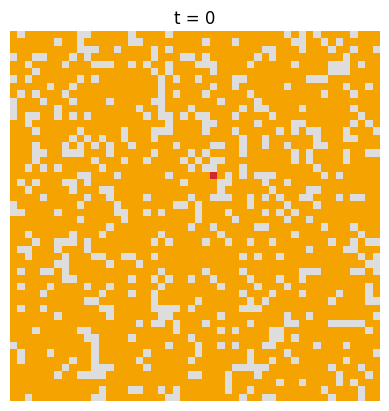

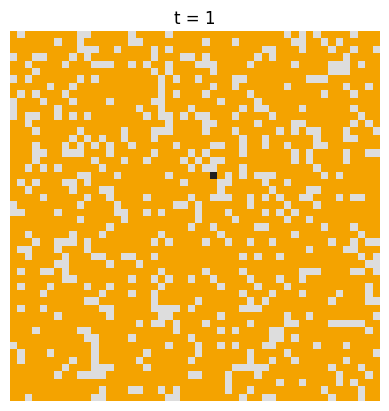

In [28]:
for i in range(2):
    show_timestep(hist, i)

## 0.9) Finishing up some details
The last thing we'll do is, in the plots plotting the state of the cells, we'll design te code such that they don't take inert cells into account. That way the number of inactive cells starts at 0% and ends at 100%, as longer as the system dies out completely.

Also, this new system will work with the newly defined dynamics. To do so, we will work with a single input which is the output of a history function:

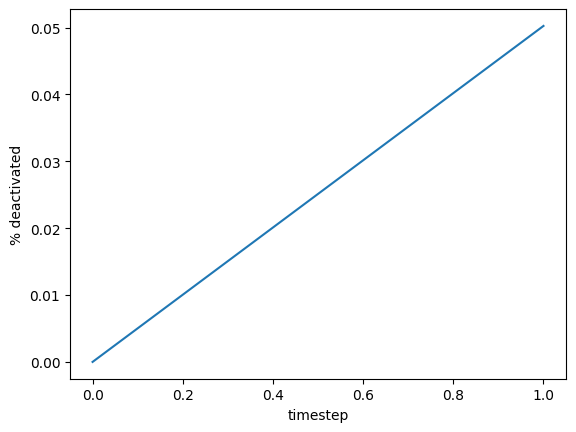

In [ ]:
def pct_deactivated(history):
    total = history[0].size - np.sum(history[0] == -1)
    return [100 * np.sum(s == -2) / total for s in history]

plt.plot(pct_deactivated(hist))
plt.xlabel('timestep')
plt.ylabel('% deactivated')
plt.show()

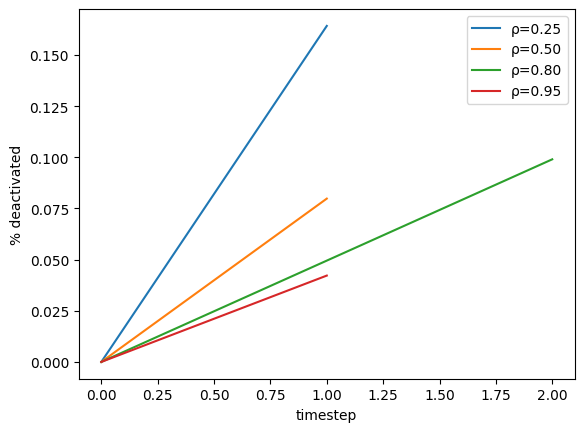

In [32]:
f_k = lambda rng: rng.geometric(p=0.3) + 1
p_succ_long = lambda k: 0.2 * np.exp(-k / 5)

hist_low  = final_history(0.25, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=50, steps=200, rng=None)
hist_mid  = final_history(0.5,  f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=50, steps=200, rng=None)
hist_high = final_history(0.8,  f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=50, steps=200, rng=None)
hist_max  = final_history(0.95, f_k, p_succ_long, p_succ_short=0.9, p_long=0.5, m=1, L=50, steps=200, rng=None)

plt.plot(pct_deactivated(hist_low),  label='ρ=0.25')
plt.plot(pct_deactivated(hist_mid),  label='ρ=0.50')
plt.plot(pct_deactivated(hist_high), label='ρ=0.80')
plt.plot(pct_deactivated(hist_max),  label='ρ=0.95')
plt.xlabel('timestep')
plt.ylabel('% deactivated')
plt.legend()
plt.savefig('pct_deactivated.png', dpi=300, bbox_inches='tight')
plt.show()